In [31]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad

def softplus(x):
    # return -1 + np.log1p(np.exp2(x)) / np.log(2)
    # return np.log1p(np.exp(x))
    return np.maximum(x, 0)
    # return np.tanh(x)
    # return x

def expected_softplus():
    integrand = lambda x: softplus(x) * norm.pdf(x)
    mu, _ = quad(integrand, -100, 100, epsabs=1e-10, epsrel=1e-10)
    return mu

def expected_softplus_squared():
    integrand = lambda x: softplus(x)**2 * norm.pdf(x)
    mu_sq, _ = quad(integrand, -100, 100, epsabs=1e-10, epsrel=1e-10)
    return mu_sq

mu = expected_softplus()
mu_sq = expected_softplus_squared()
var = mu_sq - mu**2

a = 1 / np.sqrt(var)
b = -a * mu

a, b, mu, var

(np.float64(1.712858550449663),
 np.float64(-0.683331696121481),
 0.3989422804014327,
 0.3408450569081046)

[np.float64(0.0006622432059558737), np.float64(-7.610970448312303e-05), np.float64(-0.0060727296720929375), np.float64(0.12140045186586432), np.float64(0.41171184573851916), np.float64(0.9468959481075029), np.float64(1.8841413948728138), np.float64(3.501181382660837), np.float64(6.277661470437038), np.float64(11.037264412309073), np.float64(19.191948335175336)]
[np.float64(0.9991838562602522), np.float64(1.0006397523609998), np.float64(1.31208557459363), np.float64(1.8622172595371433), np.float64(2.8266268790277094), np.float64(4.494809996212603), np.float64(7.362675460417561), np.float64(12.281256936998384), np.float64(20.709835138549252), np.float64(35.14899607746424), np.float64(59.882557412655444)]


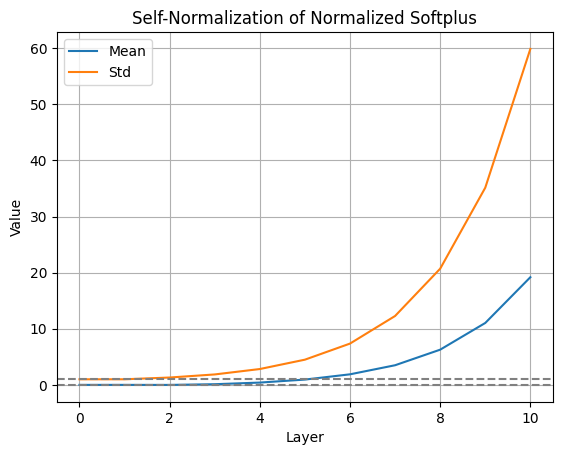

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def norm_softplus(x):
    return a * softplus(x) + b

def simulate_self_normalization(n_layers=10, n_samples=1000000):
    x = np.random.randn(n_samples)
    means = [np.mean(x)]
    stds = [np.std(x)]

    for _ in range(n_layers):
        x = norm_softplus(x)
        means.append(np.mean(x))
        stds.append(np.std(x))

    return means, stds

means, stds = simulate_self_normalization()
print(means)
print(stds)

layers = list(range(len(means)))
plt.plot(layers, means, label='Mean')
plt.plot(layers, stds, label='Std')
plt.axhline(0, color='gray', linestyle='--')
plt.axhline(1, color='gray', linestyle='--')
plt.xlabel("Layer")
plt.ylabel("Value")
plt.title("Self-Normalization of Normalized Softplus")
plt.legend()
plt.grid(True)
plt.show()
